# FCT_DAILY_DEMAND — EDA / Data Quality Review

**Schema:** `ANALYTICS.DBT_MALEX_MARTS`  
**Purpose:** Exploratory analysis to investigate potential DQ issues surfaced by the table profiler.  
**Starting point:** Daily trip volume stratified by borough — pickup and dropoff separately.

Anomalies to watch for:
- Gaps or spikes in a single borough (suggests upstream load issues)
- Dropoff dates significantly ahead of / behind pickup dates
- Boroughs with near-zero volume that suddenly drop to zero
- `NULL` borough trips — these are trips with unmatched `location_id`

In [1]:
import warnings
from pathlib import Path

import numpy as np
import yaml
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from eda_helpers import *
from eda_profile import profile, peek, summarize, schema, describe_by_type

warnings.filterwarnings('ignore')

# ── Auto-reload ───────────────────────────────────────────────────────────────
%load_ext autoreload
%autoreload 2

from eda_helpers import *

# ── Rendering backend ─────────────────────────────────────────────────────────
%matplotlib inline

# ── Theme & global chart defaults ─────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')   # Solarize_Light2 has yellow background
plt.rcParams.update({
    'axes.titlesize':    24,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.titlesize':  16,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── DataFrame table styling ──────────────────────────────────────────────────
# Outer border: 2px, 20% black — thicker than cell borders.
# Cell borders: 1.5px, 15% black — distinct but not heavy.
# Header row: light gray background to visually separate from data.
display(HTML("""
<style>
table.dataframe {
    border-collapse: collapse !important;
    border: 2px solid rgba(0,0,0,0.2) !important;
}
table.dataframe td, table.dataframe th {
    border: 1.5px solid rgba(0,0,0,0.15) !important;
}
table.dataframe thead th {
    background-color: #f0f0f0 !important;
    font-weight: bold !important;
}
</style>
"""))

# ── Connection config ──────────────────────────────────────────────────────────
DBT_PROFILES  = Path.home() / '.dbt' / 'profiles.yml'
DBT_PROFILE   = 'nyc_taxi'
TARGET_SCHEMA = 'DBT_MALEX_MARTS'

def _load_creds():
    """Parse profiles.yml and return the active target's connection dict."""
    with open(DBT_PROFILES) as f:
        p = yaml.safe_load(f)
    target = p[DBT_PROFILE]['target']
    return p[DBT_PROFILE]['outputs'][target]

def _connect():
    """Open a Snowflake connection using key-pair auth from profiles.yml."""
    from cryptography.hazmat.primitives.serialization import (
        load_pem_private_key, Encoding, PrivateFormat, NoEncryption
    )
    c = _load_creds()
    kw = dict(
        account   = c['account'],
        user      = c['user'],
        warehouse = c.get('warehouse'),
        database  = c.get('database'),
        schema    = TARGET_SCHEMA,
    )
    if c.get('role'):
        kw['role'] = c['role']
    key_path = Path(c['private_key_path']).expanduser()
    with open(key_path, 'rb') as f:
        pk = load_pem_private_key(f.read(), password=None)
    kw['private_key'] = pk.private_bytes(
        encoding=Encoding.DER, format=PrivateFormat.PKCS8,
        encryption_algorithm=NoEncryption(),
    )
    return snowflake.connector.connect(**kw)

conn = _connect()
print(f'Connected  →  ANALYTICS.{TARGET_SCHEMA}')

def sql(query: str) -> pd.DataFrame:
    """Execute SQL and return a DataFrame with native pandas dtypes when possible.

    Uses Snowflake's Arrow-backed fetch_pandas_all() for SELECT queries — NUMBER
    columns arrive as float64 instead of decimal.Decimal. SHOW/DESC/CALL return
    JSON-format result sets that don't support Arrow, so those fall back to
    fetchall(). Column names are lower-cased.
    """
    cur = conn.cursor()
    cur.execute(query)
    try:
        df = cur.fetch_pandas_all()
    except snowflake.connector.errors.NotSupportedError:
        # SHOW/DESC/CALL etc. — JSON-format result, no Arrow
        rows = cur.fetchall()
        cols = [d[0] for d in cur.description] if cur.description else []
        df = pd.DataFrame(rows, columns=cols)
    df.columns = [c.lower() for c in df.columns]
    return df

Connected  →  ANALYTICS.DBT_MALEX_MARTS


# Data Gathering

Set `FORCE_RELOAD = True` below to re-query Snowflake. Otherwise, if DataFrames already exist in memory (from a prior run), the queries are skipped and cached data is reused. This means you can **Run All** after changing `rcParams` or chart code without waiting for SQL.

Dataframes are defined here.

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  FORCE_RELOAD — flip to True to re-query Snowflake         ║
# ║  Leave False to reuse cached DataFrames on Run All          ║
# ╚══════════════════════════════════════════════════════════════╝
# FORCE_RELOAD = True
FORCE_RELOAD = False

## pickup_df: Pickup Date
pickup_df: pickup_date, borough, trip_cnt (aggregated)
- Query: daily trip count by pickup borough.
- Grain: one row per (pickup_date, borough).
- COALESCE maps NULL pickup_borough to a visible label so those trips aren't silently dropped.

In [3]:
diag = sql("""
    SELECT 
        CURRENT_ROLE()      AS role,
        CURRENT_WAREHOUSE() AS warehouse,
        CURRENT_DATABASE()  AS database,
        CURRENT_SCHEMA()    AS schema
""")
print(diag.to_string(index=False))

       role    warehouse  database          schema
TRANSFORMER TRANSFORMING ANALYTICS DBT_MALEX_MARTS


In [4]:
tables = sql("""
    SHOW TABLES IN SCHEMA ANALYTICS.DBT_MALEX_MARTS
""")
print(tables[['name', 'schema_name']].to_string(index=False))

            name     schema_name
        DIM_DATE DBT_MALEX_MARTS
       DIM_ZONES DBT_MALEX_MARTS
FCT_DAILY_DEMAND DBT_MALEX_MARTS
       FCT_TRIPS DBT_MALEX_MARTS


In [5]:
# Query: daily trip count by pickup borough.
# Grain: one row per (pickup_date, borough).
# COALESCE maps NULL pickup_borough to a visible label so those trips aren't silently dropped.
if FORCE_RELOAD or 'pickup_df' not in dir():
    pickup_df = sql("""
        SELECT
            pickup_date,
            COALESCE(pickup_borough, '(null borough)') AS borough,
            COUNT(demand_id)                             AS trip_cnt
        FROM   fct_daily_demand
        GROUP  BY 1, 2
        ORDER  BY 1, 2
    """)
    pickup_df['pickup_date'] = pd.to_datetime(pickup_df['pickup_date'])
    print(f'Queried:  {len(pickup_df):,} rows  |  '
          f'{pickup_df["pickup_date"].min().date()} → {pickup_df["pickup_date"].max().date()}')
else:
    print(f'Cached:   {len(pickup_df):,} rows  |  '
          f'{pickup_df["pickup_date"].min().date()} → {pickup_df["pickup_date"].max().date()}')

Queried:  5,835 rows  |  2024-01-01 → 2025-12-31


### Dataframe Profile

In [6]:
profile(pickup_df, charts=False) 

#### Summary

#### Sample rows

,pickup_date,borough,trip_cnt
0,2024-01-01,bronx,36
1,2024-01-01,brooklyn,59
2,2024-01-01,ewr,1
3,2024-01-01,manhattan,65
4,2024-01-01,n/a,1


#### Schema

,column,dtype,non_null_pct,n_unique,sample_values
0,pickup_date,datetime64[ns],100.0%,731,"Timestamp('2024-01-01 00:00:00'), Timestamp('2..."
1,borough,object,100.0%,8,"'bronx', 'brooklyn', 'ewr'"
2,trip_cnt,int64,100.0%,46,"36, 59, 1"


...

,count,mean,std,min,25%,50%,75%,max,%zero,%neg,skew
trip_cnt,"5,835",29.727,28.646,1,1,35,61,69,0.0%,0.0%,0.161


**Categorical / object columns**

,column,count,unique,top,top_freq,%blank
0,borough,"5,835",8,bronx,731 (12.5%),0.0%


**Datetime columns**

,column,count,min,max,range_days
0,pickup_date,"5,835",2024-01-01 00:00:00,2025-12-31 00:00:00,730


### Trip Count Statistics Table

In [7]:
display(
    pickup_df.groupby("borough")["trip_cnt"]
    .describe(percentiles=[0.01, 0.02, 0.03, 0.25, 0.5, 0.75, 0.97, 0.98, 0.99])
    .sort_values("max", ascending=False)
    #.T
    .style.format("{:,.0f}")
)

,count,mean,std,min,1%,2%,3%,25%,50%,75%,97%,98%,99%,max
borough,,,,,,,,,,,,,,
queens,731,64,3,52,57,59,59,63,65,66,68,68,69,69
manhattan,731,65,1,63,63,64,64,65,66,66,66,66,66,67
brooklyn,731,60,1,49,55,56,57,59,60,60,61,61,61,61
bronx,731,39,2,30,35,36,36,38,40,41,42,42,42,43
staten island,718,5,3,1,1,1,1,3,5,7,10,11,12,15
ewr,731,1,0,1,1,1,1,1,1,1,1,1,1,1
n/a,731,1,0,1,1,1,1,1,1,1,1,1,1,1
unknown,731,1,0,1,1,1,1,1,1,1,1,1,1,1


## sample_df: full field sample
- 10% random sample (`SAMPLE BERNOULLI`) for string field profiling
- Includes all fields from FCT_DAILY_DEMAND to allow profiling each field.
- NOTE FCT_DAILY_DEMAND is an aggregated table, so distributions on this dataset are not raw, which can impact signals visible in the fields. 

In [8]:
# String/categorical field sample — 10% row-level random sample.
# SAMPLE BERNOULLI (10) selects each row independently at ~10% probability.
# Uses SELECT * to discover all available columns — avoids hardcoding names
# that may not exist in the materialized table.
if FORCE_RELOAD or 'sample_df' not in dir():
    sample_df = sql("""
        SELECT *
        FROM fct_daily_demand
        SAMPLE BERNOULLI (10)
        WHERE (avg_distance_miles >0) AND (avg_fare >0)
    """)
    print(f'Queried: {len(sample_df):,} rows  |  {len(sample_df.columns)} columns')

    # Show which columns are string/object type for plot_string_profile
    # Categorize columns by dtype
    str_cols = [c for c in sample_df.columns if sample_df[c].dtype == "object"]
    num_cols = sample_df.select_dtypes(include='number').columns.tolist()
    date_cols = sample_df.select_dtypes(include=['datetime', 'datetimetz']).columns.tolist()
    
    print(f'String columns  ({len(str_cols)}): {str_cols}')
    print(f'Numeric columns ({len(num_cols)}): {num_cols}')
    print(f'Date columns    ({len(date_cols)}): {date_cols}')
else:
    print(f'Cached:  {len(sample_df):,} rows')


Queried: 17,048 rows  |  43 columns
String columns  (5): ['demand_id', 'pickup_date', 'pickup_borough', 'pickup_zone', 'pickup_service_zone']
Numeric columns (38): ['pickup_year', 'pickup_month', 'day_of_week', 'is_weekend', 'is_holiday', 'pickup_location_id', 'trip_count', 'airport_pickup_count', 'null_batch_trip_count', 'fare_exception_count', 'zero_distance_count', 'cross_borough_count', 'adjusted_trip_count', 'has_null_batch_ind', 'null_batch_pct', 'total_fare_revenue', 'total_revenue', 'total_tips', 'avg_fare', 'avg_distance_miles', 'avg_duration_minutes', 'avg_tip', 'credit_card_tip_rate_pct', 'credit_card_trips', 'cash_trips', 'morning_rush_trips', 'evening_rush_trips', 'overnight_trips', 'temp_max_f', 'temp_min_f', 'temp_avg_f', 'precipitation_in', 'snowfall_in', 'snow_depth_in', 'avg_wind_speed_mph', 'rain_day_ind', 'snow_day_ind', 'freezing_day_ind']
Date columns    (0): []


In [9]:
display(sample_df.sample(10))

,demand_id,pickup_date,pickup_year,pickup_month,day_of_week,is_weekend,is_holiday,pickup_location_id,pickup_borough,pickup_zone,...,temp_max_f,temp_min_f,temp_avg_f,precipitation_in,snowfall_in,snow_depth_in,avg_wind_speed_mph,rain_day_ind,snow_day_ind,freezing_day_ind
11181,7d84f11c598c7e9b2ab6705d061da9a0,2025-05-01,2025,5,4,0,0.0,159,bronx,melrose south,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12188,5d005940af9059e796063e291f1b4c5d,2025-06-11,2025,6,3,0,0.0,234,manhattan,union sq,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11049,0bf57f916ca5118caf99313021385941,2025-04-25,2025,4,5,0,0.0,211,manhattan,soho,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8891,b352d65fef63510eae0286f0f9b4d72e,2025-01-24,2025,1,5,0,0.0,223,queens,steinway,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2042,65c4e257ffbd2e13c98c1ad264aae2c2,2024-04-03,2024,4,3,0,0.0,165,brooklyn,midwood,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
514,02727965a943543a480e8c167e0d8613,2024-01-23,2024,1,2,0,0.0,194,manhattan,randalls island,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7903,389673178d3fa6fd9969a3bd491541a7,2024-12-12,2024,12,4,0,0.0,63,brooklyn,cypress hills,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1528,11e5836386203a0bc98fcd79fdcf36e2,2024-03-11,2024,3,1,0,0.0,98,queens,fresh meadows,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
705,1010eed6b7e410401c04923cd7f46502,2024-02-02,2024,2,5,0,0.0,42,manhattan,central harlem north,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
973,85e0eeef633aa35c6dfa31ab77c9e3a8,2024-02-14,2024,2,3,0,0.0,264,unknown,n/a,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
import pandas as pd

df_inventory = pd.DataFrame([
    {
        "name":    name,
        "rows":    f"{obj.shape[0]:,}",
        "columns": obj.shape[1],
    }
    for name, obj in sorted(vars().items())
    if isinstance(obj, pd.DataFrame)
])

display(df_inventory.style.hide(axis="index"))

name,rows,columns
diag,1,4
pickup_df,"5,835",3
sample_df,"17,048",43
tables,4,26


### Dataframe Profile

In [11]:
profile(sample_df, charts=False) 

#### Summary

> [!WARNING]
> **Issues flagged**
>
> - **10 column(s) 100% null:** `temp_max_f`, `temp_min_f`, `temp_avg_f`, `precipitation_in`, `snowfall_in`, `snow_depth_in`, `avg_wind_speed_mph`, `rain_day_ind`, `snow_day_ind`, `freezing_day_ind`
> - **3 column(s) with a single value:** `null_batch_trip_count`, `has_null_batch_ind`, `null_batch_pct`
> - **2 high-cardinality column(s) (≥ 95% unique, possible PKs):** `demand_id`, `avg_fare`

#### Sample rows

,demand_id,pickup_date,pickup_year,pickup_month,day_of_week,is_weekend,is_holiday,pickup_location_id,pickup_borough,pickup_zone,pickup_service_zone,trip_count,airport_pickup_count,null_batch_trip_count,fare_exception_count,zero_distance_count,cross_borough_count,adjusted_trip_count,has_null_batch_ind,null_batch_pct,total_fare_revenue,total_revenue,total_tips,avg_fare,avg_distance_miles,avg_duration_minutes,avg_tip,credit_card_tip_rate_pct,credit_card_trips,cash_trips,morning_rush_trips,evening_rush_trips,overnight_trips,temp_max_f,temp_min_f,temp_avg_f,precipitation_in,snowfall_in,snow_depth_in,avg_wind_speed_mph,rain_day_ind,snow_day_ind,freezing_day_ind
0,320d99c8de24ea9c58805ef1edb0a7fb,2024-01-01,2024,1,1,0,1.0,9,queens,auburndale,boro zone,4,0,0,0,1,2,4,0,0.0,0.0,0.0,0.0,51.700000,10.595000,18.250000,9.000000,100.000000,2,0,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8fdc7d604c167f4661b3e322a042ebca,2024-01-01,2024,1,1,0,1.0,16,queens,bayside,boro zone,5,0,0,0,1,0,5,0,0.0,0.0,0.0,0.0,15.806000,1.884000,6.800000,0.000000,NaN,0,0,0,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,c879e51cb6448165cfd863857f5b8394,2024-01-01,2024,1,1,0,1.0,18,bronx,bedford park,boro zone,5,0,0,0,2,2,5,0,0.0,0.0,0.0,0.0,25.494000,2.074000,16.600000,0.000000,0.000000,1,1,1,0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f056feafb63d0e84ee7b7914697401c8,2024-01-01,2024,1,1,0,1.0,35,brooklyn,brownsville,boro zone,10,0,0,0,5,8,10,0,0.0,0.0,0.0,0.0,42.176000,5.435000,32.500000,0.000000,0.000000,3,0,2,0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ca04ee044e7678bd74aea2cb0ed07f24,2024-01-01,2024,1,1,0,1.0,49,brooklyn,clinton hill,boro zone,44,0,0,0,6,27,44,0,0.0,0.0,0.0,0.0,31.414318,4.613409,22.477273,1.671591,66.666667,12,1,2,2,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Schema

...

#### Descriptive statistics

**Numeric columns**

,count,mean,std,min,25%,50%,75%,max,%zero,%neg,skew
pickup_year,"17,048","2,024.510",0.500,"2,024","2,024","2,025","2,025","2,025",0.0%,0.0%,-0.041
pickup_month,"17,048",6.590,3.436,1,4,7,10,12,0.0%,0.0%,-0.025
day_of_week,"17,048",2.987,2.004,0,1,3,5,6,14.7%,0.0%,0.003
is_weekend,"17,048",0.288,0.453,0,0,0,1,1,71.2%,0.0%,0.936
is_holiday,"17,028",0.011,0.106,0,0,0,0,1,98.9%,0.0%,9.184
pickup_location_id,"17,048",134.362,76.472,1,68,137,200,265,0.0%,0.0%,-0.023
trip_count,"17,048",514.682,"1,146.814",1,10,30,218,"8,627",0.0%,0.0%,2.948
airport_pickup_count,"17,048",36.870,430.429,0,0,0,0,"7,941",99.2%,0.0%,12.544
null_batch_trip_count,"17,048",0,0,0,0,0,0,0,100.0%,0.0%,0
fare_exception_count,"17,048",22.127,57.438,0,0,1,15,"1,325",37.4%,0.0%,5.740


**Categorical / object columns**

,column,count,unique,top,top_freq,%blank
0,demand_id,"17,048",17048,320d99c8de24ea9c58805ef1edb0a7fb,1 (0.0%),0.0%
1,pickup_date,"17,048",731,2024-03-27,43 (0.3%),0.0%
2,pickup_borough,"17,048",8,manhattan,"4,634 (27.2%)",0.0%
3,pickup_zone,"17,048",259,corona,128 (0.8%),0.0%
4,pickup_service_zone,"17,048",5,boro zone,"13,022 (76.4%)",0.0%


## Explore Grain Elements and Cardinality

Boundary Conditions by column

In [12]:
cols = [
    "demand_id",
    "pickup_date",
    "pickup_borough",
    "pickup_zone",
    "pickup_location_id",
    "pickup_service_zone",
    "is_holiday",
    "is_weekend",
    "day_of_week",
    "pickup_month",
    "pickup_year",
]

summary = sample_df[cols].agg(["nunique", "min", "max"]).T
summary.columns = ["distinct_count", "min", "max"]

display(summary.style.format({"distinct_count": "{:,}"}))

,distinct_count,min,max
demand_id,"17,048",000a3949d58927255f43cda6f234caae,fffac5f1d30943dbe45ad666db826d60
pickup_date,731,2024-01-01,2025-12-31
pickup_borough,8,bronx,unknown
pickup_zone,259,allerton/pelham gardens,yorkville west
pickup_location_id,260,1,265
pickup_service_zone,5,airports,yellow zone
is_holiday,2.0,0.000000,1.000000
is_weekend,2,0,1
day_of_week,7,0,6
pickup_month,12,1,12


**FCT_DAILY_DEMAND GRAIN:
- PICKUP_DATE
- PICKUP_ZONE

Table below shows the unique count of the fields at the table grain (pickup_date, pickup_zone).

In [13]:
cols = [
    "demand_id",
    "pickup_borough",
    "pickup_location_id",
    "pickup_service_zone",
    "is_holiday",
    "is_weekend",
    "day_of_week",
    "pickup_month",
    "pickup_year",
]

daily_zone_distinct_df = (
    sample_df.groupby(["pickup_date", "pickup_zone"])[cols]
    .nunique()
    .reset_index()
)

display(daily_zone_distinct_df.head())

,pickup_date,pickup_zone,demand_id,pickup_borough,pickup_location_id,pickup_service_zone,is_holiday,is_weekend,day_of_week,pickup_month,pickup_year
0,2024-01-01,auburndale,1,1,1,1,1,1,1,1,1
1,2024-01-01,bayside,1,1,1,1,1,1,1,1,1
2,2024-01-01,bedford park,1,1,1,1,1,1,1,1,1
3,2024-01-01,brownsville,1,1,1,1,1,1,1,1,1
4,2024-01-01,clinton hill,1,1,1,1,1,1,1,1,1


# Numerics


## Known/Expected Distributions
Simple checks to make sure fields are populated as expected.

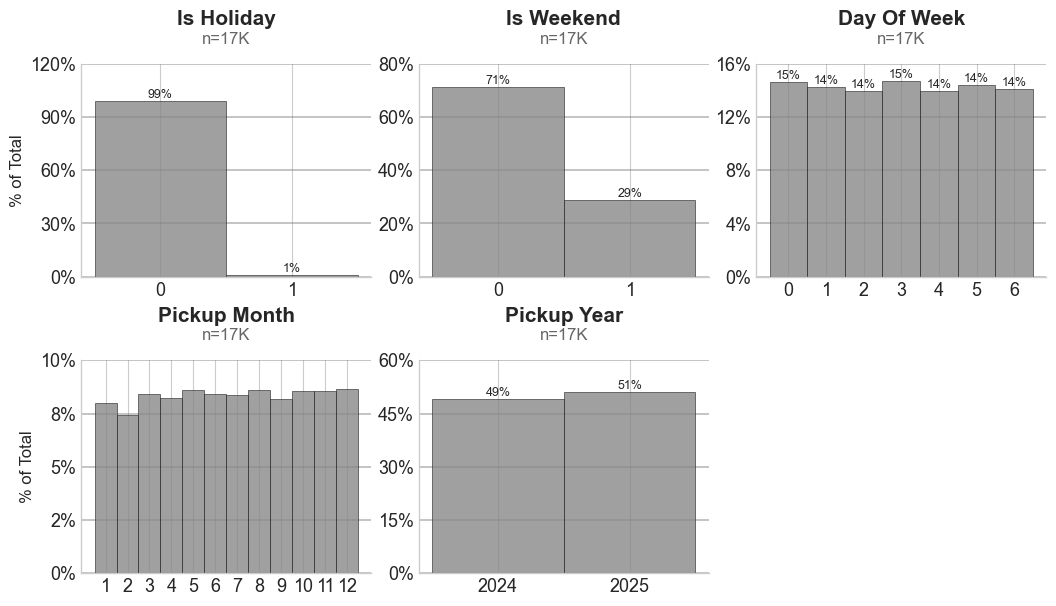

In [14]:
plot_histograms(
    df     = sample_df,
    fields = ['is_holiday', 'is_weekend', 'day_of_week', 'pickup_month', 'pickup_year'],
    label_threshold = 10,    # label any panel with < 8 bars
)

Everything checks out.  Only 2 holidays/year.  What are they?

In [15]:
holidays = pd.to_datetime(
    sample_df.loc[sample_df['is_holiday'] == 1, 'pickup_date']
).drop_duplicates()

(pd.DataFrame({
    'sort_key': holidays.dt.strftime('%m-%d'),
    'pretty':   holidays.dt.strftime('%b %d'),
 })
 .drop_duplicates('sort_key')
 .sort_values('sort_key')
 ['pretty']
 .tolist())

['Jan 01', 'Jul 04', 'Nov 22', 'Nov 28', 'Dec 25']

- Jan 1st
- July 4th
- Nov Thanksgiving (Floating)
- Dec 25th

## Trip Volume by Type
Demonstrate the # of Trips and the relative frequency of the different "types" of trips

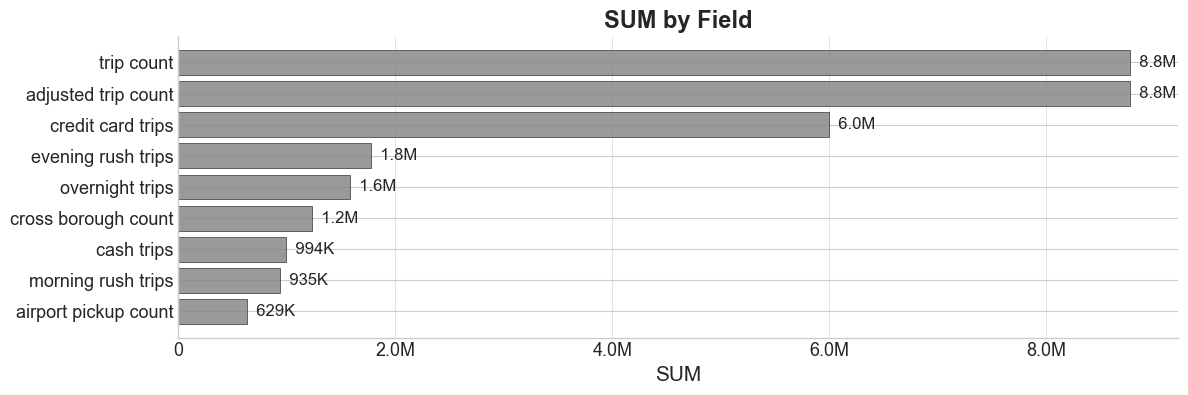

In [16]:
plot_field_aggregates(
    df     = sample_df,
    fields = [
        'trip_count', 'adjusted_trip_count', 'airport_pickup_count',
        'cross_borough_count', 'cash_trips', 'evening_rush_trips',
        'morning_rush_trips', 'credit_card_trips', 'overnight_trips',
    ],
)


Summary
- Credit Card Trips ~67%
- Evening Rush Trips about 20%, Morning Rush Trips about 1/2 that (10%).
- Cross Borough Trips about 15%, differs considerably by Borough.
- Airport Pickup Trips about ~7%

## Trip Volume by Type - By Borough

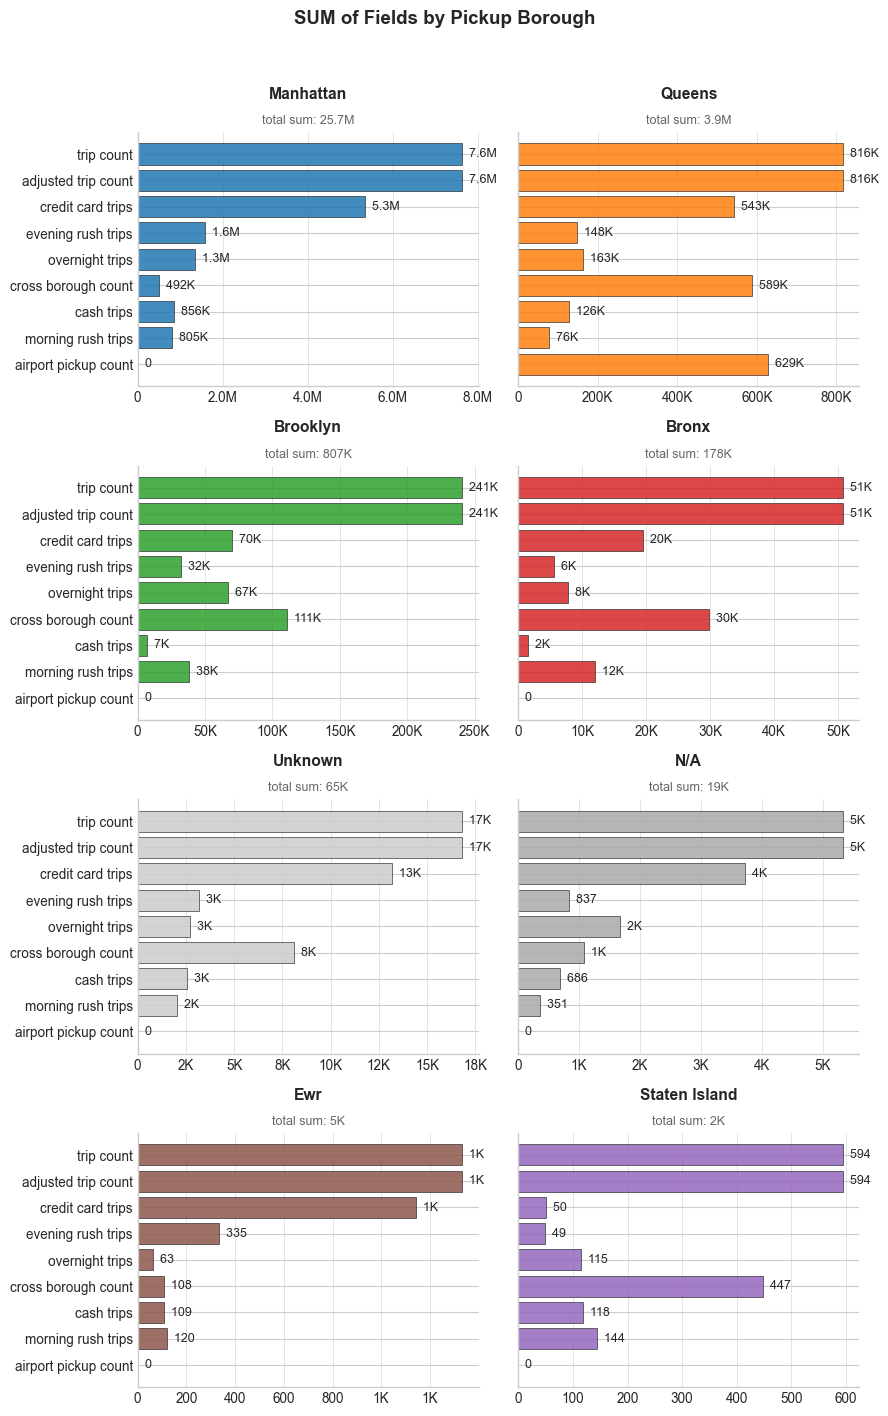

In [17]:
plot_field_aggregates_by_group(
    df          = sample_df,
    shared_x    = False,
    group_field = 'pickup_borough',
    max_cols    = 2,
    fields      = [
        'trip_count', 'adjusted_trip_count', 'airport_pickup_count',
        'cross_borough_count', 'cash_trips', 'evening_rush_trips',
        'morning_rush_trips', 'credit_card_trips', 'overnight_trips',
    ],
)


Summary
- Cross-borough Trips are way frequent for trips that start in **non-Manhattan** boroughs

## Exception Fields
Explore overall value of the Exceptions counts

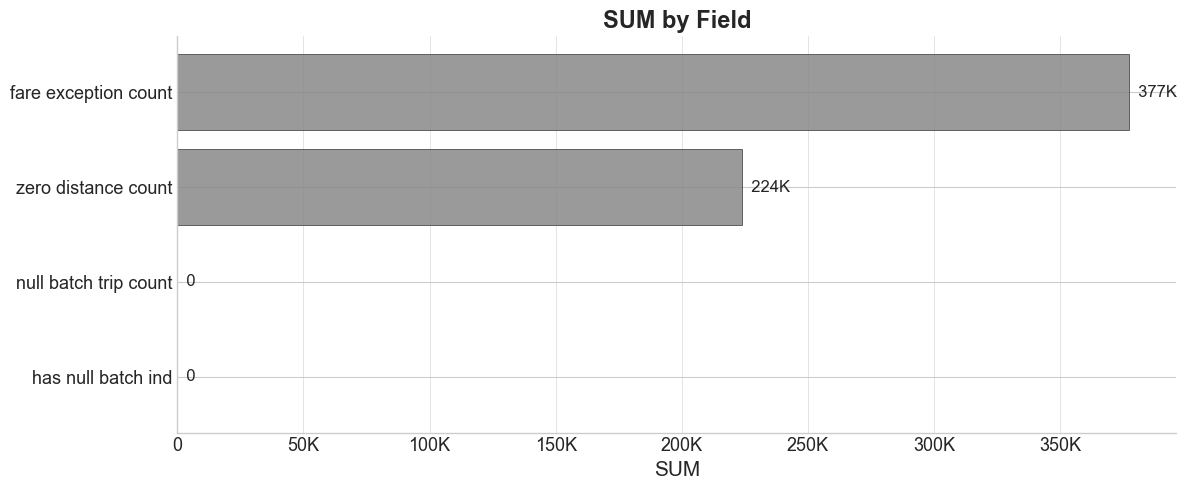

In [18]:
plot_field_aggregates(
    df     = sample_df,
    panel_height = 5.0,    # 20% taller than the auto 4.05
    fields = [
        'fare_exception_count','null_batch_trip_count',
        'zero_distance_count', 'has_null_batch_ind'
    ],
)


## Revenue
Where is it coming from?  Not sure this tells the picture

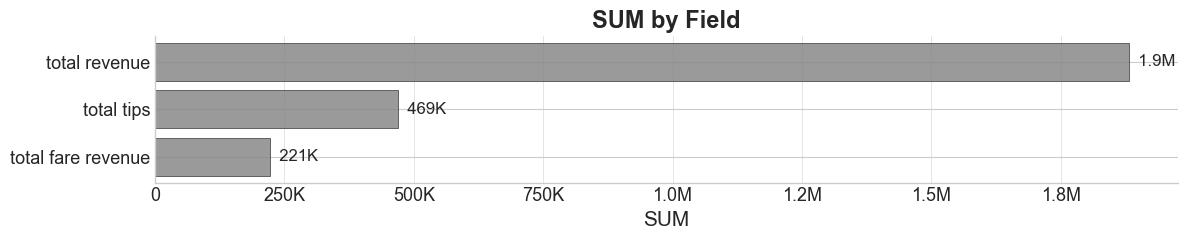

In [19]:
plot_field_aggregates(
    df     = sample_df,
    fields = [
        'total_fare_revenue','total_revenue','total_tips'
    ],
)

# Trips
Explore distributions and relationships between several trip related metrics:
- Avg Distance Miles
- Avg Duration Minutes
- Avg Fare
- Avg Tip

## Distributions

### Avg Distance Miles | Distribution

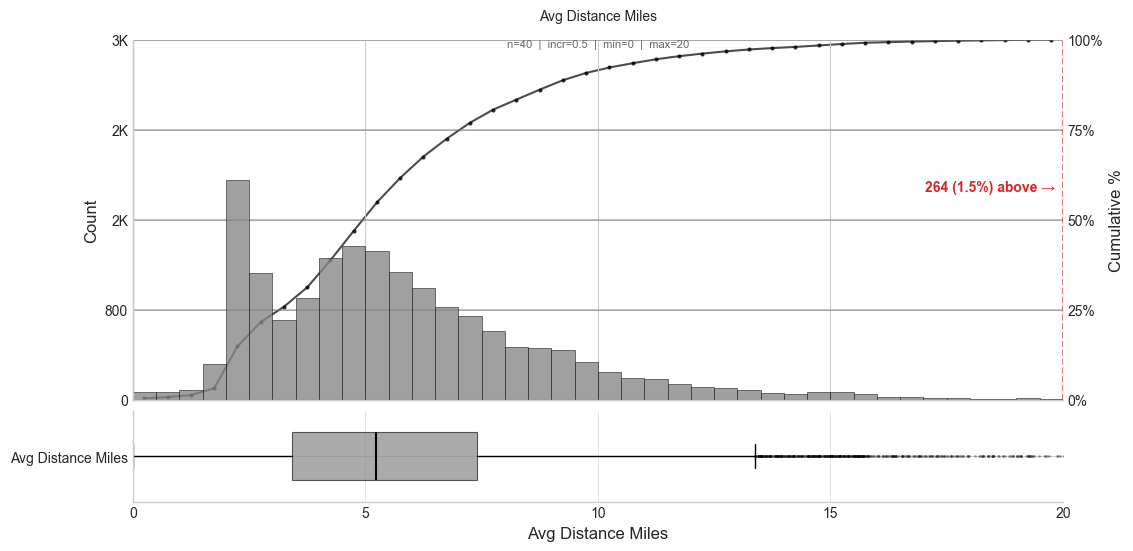

In [20]:
plot_distribution(
            df    = sample_df,                  # DataFrame to plot
            field = 'avg_distance_miles',    # numeric column (used by both hist + box)

            # ── Binning (shared) ──────────────────────────────────────────
            # bin_cnt    = 20,                # number of bins (ignored if bin_incr set)
              bin_incr   = .5,              # fixed bin width — overrides bin_cnt
              bin_min    = 0,                 # left boundary — constrains axis + annotates excluded
              bin_max    = 20,                # right boundary — constrains axis + annotates excluded
            # bin_on_int = False,             # True = snap bin edges to integers

            # ── Clipping (histogram only — red boundary lines + count) ────
            # clip_min   = None,              # annotate records below (if different from bin_min)
            # clip_max   = None,              # annotate records above (if different from bin_max)

            # ── Histogram options ─────────────────────────────────────────
            # pct               = False,      # True = y-axis shows % of total
            # show_labels       = False,      # True = count/% on top of each bar
              cumulative_line   = True,      # True = Pareto-style cumulative % (0–100%)
            # cumulative_behind = True,       # True = line behind bars, False = in front

            # ── Boxplot options ───────────────────────────────────────────
            # group_field       = 'borough',  # one box per value, sorted by median desc
            # show_outliers     = True,       # dots beyond whiskers
            # show_means        = False,      # diamond marker for mean
            # whis              = 1.5,        # whisker extent (IQR multiplier). (0,100) for min/max.
            # show_box_labels   = False,      # annotate Q1, median, Q3, whisker values
            # show_strip        = False,      # jittered data points on boxes
            # strip_max_points  = 5000,       # auto-sample threshold for strip

            # ── Layout ────────────────────────────────────────────────────
            # height_ratio = (4, 1),          # (histogram, boxplot) vertical split
            # panel_width  = None,            # figure width (default = CHART_WIDTH)
            # panel_height = 6.0,             # total figure height
        )

### Avg Durations Minutes | Distribution

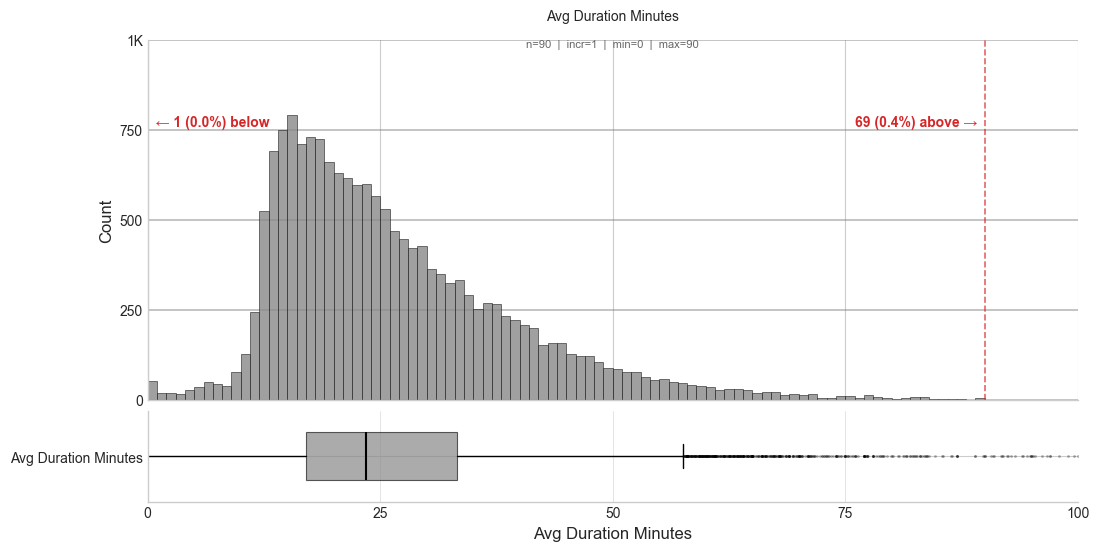

In [21]:
plot_distribution(
            df    = sample_df,                  # DataFrame to plot
            field = 'avg_duration_minutes',    # numeric column (used by both hist + box)

            # ── Binning (shared) ──────────────────────────────────────────
            # bin_cnt    = 20,                # number of bins (ignored if bin_incr set)
              bin_incr   = 1,              # fixed bin width — overrides bin_cnt
              bin_min    = 0,                 # left boundary — constrains axis + annotates excluded
              bin_max    = 90,                # right boundary — constrains axis + annotates excluded
            # bin_on_int = False,             # True = snap bin edges to integers

            # ── Clipping (histogram only — red boundary lines + count) ────
            # clip_min   = None,              # annotate records below (if different from bin_min)
            # clip_max   = None,              # annotate records above (if different from bin_max)

            # ── Histogram options ─────────────────────────────────────────
            # pct               = False,      # True = y-axis shows % of total
            # show_labels       = False,      # True = count/% on top of each bar
            # cumulative_line   = False,      # True = Pareto-style cumulative % (0–100%)
            # cumulative_behind = True,       # True = line behind bars, False = in front

            # ── Boxplot options ───────────────────────────────────────────
            # group_field       = 'borough',  # one box per value, sorted by median desc
            # show_outliers     = True,       # dots beyond whiskers
            # show_means        = False,      # diamond marker for mean
            # whis              = 1.5,        # whisker extent (IQR multiplier). (0,100) for min/max.
            # show_box_labels   = False,      # annotate Q1, median, Q3, whisker values
            # show_strip        = False,      # jittered data points on boxes
            # strip_max_points  = 5000,       # auto-sample threshold for strip

            # ── Layout ────────────────────────────────────────────────────
            # height_ratio = (4, 1),          # (histogram, boxplot) vertical split
            # panel_width  = None,            # figure width (default = CHART_WIDTH)
            # panel_height = 6.0,             # total figure height
        )

### Avg Fare ($) | Distribution

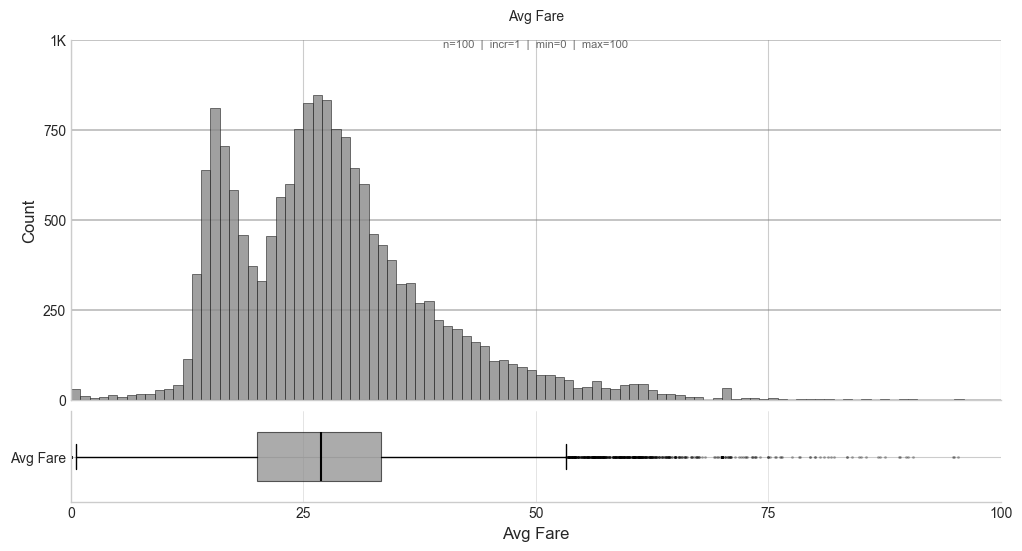

In [22]:
plot_distribution(
            df    = sample_df,                  # DataFrame to plot
            field = 'avg_fare',    # numeric column (used by both hist + box)

            # ── Binning (shared) ──────────────────────────────────────────
            # bin_cnt    = 20,                # number of bins (ignored if bin_incr set)
              bin_incr   = 1,              # fixed bin width — overrides bin_cnt
              bin_min    = 0,                 # left boundary — constrains axis + annotates excluded
              bin_max    = 100,                # right boundary — constrains axis + annotates excluded
            # bin_on_int = False,             # True = snap bin edges to integers

            # ── Clipping (histogram only — red boundary lines + count) ────
            # clip_min   = None,              # annotate records below (if different from bin_min)
            # clip_max   = None,              # annotate records above (if different from bin_max)

            # ── Histogram options ─────────────────────────────────────────
            # pct               = False,      # True = y-axis shows % of total
            # show_labels       = False,      # True = count/% on top of each bar
            # cumulative_line   = False,      # True = Pareto-style cumulative % (0–100%)
            # cumulative_behind = True,       # True = line behind bars, False = in front

            # ── Boxplot options ───────────────────────────────────────────
            # group_field       = 'borough',  # one box per value, sorted by median desc
            # show_outliers     = True,       # dots beyond whiskers
            # show_means        = False,      # diamond marker for mean
            # whis              = 1.5,        # whisker extent (IQR multiplier). (0,100) for min/max.
            # show_box_labels   = False,      # annotate Q1, median, Q3, whisker values
            # show_strip        = False,      # jittered data points on boxes
            # strip_max_points  = 5000,       # auto-sample threshold for strip

            # ── Layout ────────────────────────────────────────────────────
            # height_ratio = (4, 1),          # (histogram, boxplot) vertical split
            # panel_width  = None,            # figure width (default = CHART_WIDTH)
            # panel_height = 6.0,             # total figure height
        )

Summary
- Bi-modalal, think it has to do with a certain type of short trips that might have higher fee structure (e.g. Airport or Bridge Fees)

### Avg Tip ($) | Distribution

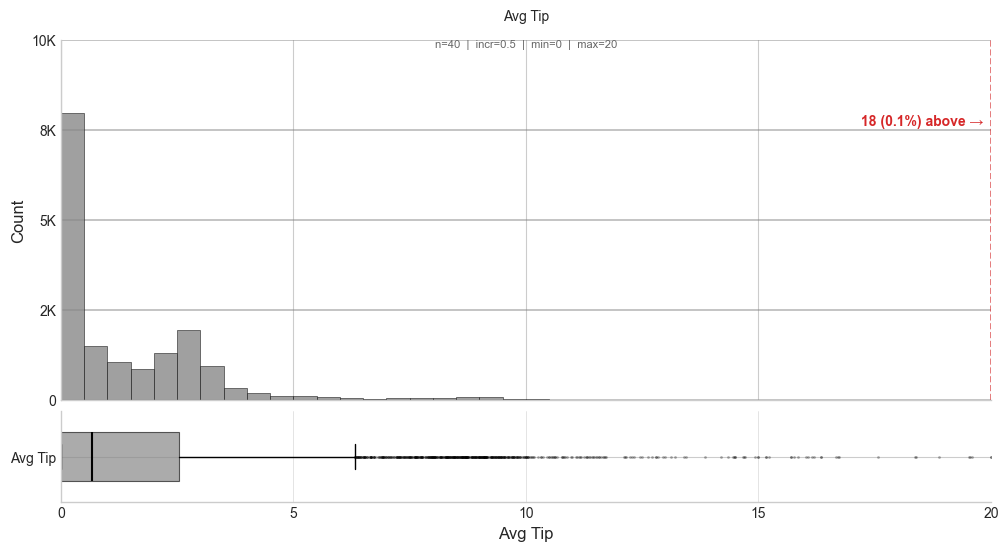

In [23]:
plot_distribution(
            df    = sample_df,                  # DataFrame to plot
            field = 'avg_tip',    # numeric column (used by both hist + box)

            # ── Binning (shared) ──────────────────────────────────────────
            # bin_cnt    = 20,                # number of bins (ignored if bin_incr set)
              bin_incr   = .5,              # fixed bin width — overrides bin_cnt
              bin_min    = 0,                 # left boundary — constrains axis + annotates excluded
              bin_max    = 20,                # right boundary — constrains axis + annotates excluded
            # bin_on_int = False,             # True = snap bin edges to integers

            # ── Clipping (histogram only — red boundary lines + count) ────
            # clip_min   = None,              # annotate records below (if different from bin_min)
            # clip_max   = None,              # annotate records above (if different from bin_max)

            # ── Histogram options ─────────────────────────────────────────
            # pct               = False,      # True = y-axis shows % of total
            # show_labels       = False,      # True = count/% on top of each bar
            # cumulative_line   = False,      # True = Pareto-style cumulative % (0–100%)
            # cumulative_behind = True,       # True = line behind bars, False = in front

            # ── Boxplot options ───────────────────────────────────────────
            # group_field       = 'borough',  # one box per value, sorted by median desc
            # show_outliers     = True,       # dots beyond whiskers
            # show_means        = False,      # diamond marker for mean
            # whis              = 1.5,        # whisker extent (IQR multiplier). (0,100) for min/max.
            # show_box_labels   = False,      # annotate Q1, median, Q3, whisker values
            # show_strip        = False,      # jittered data points on boxes
            # strip_max_points  = 5000,       # auto-sample threshold for strip

            # ── Layout ────────────────────────────────────────────────────
            # height_ratio = (4, 1),          # (histogram, boxplot) vertical split
            # panel_width  = None,            # figure width (default = CHART_WIDTH)
            # panel_height = 6.0,             # total figure height
        )

## Scatterplots

### Avg Distance Miles vs Avg Fare
- What this means for your portfolio narrative
If you want a chart that shows "as distance goes up, fare goes up," you've got two clean options:

- Switch to trip-level data (fct_trips) — each row is one trip; trip_distance vs fare_amount should show a much stronger r, around 0.7-0.9.
- Stay at zone-day grain but stratify — render per-borough scatters (option above). The story becomes more nuanced: "within each borough, distance drives fare; across boroughs, surcharges and rate structures dominate."

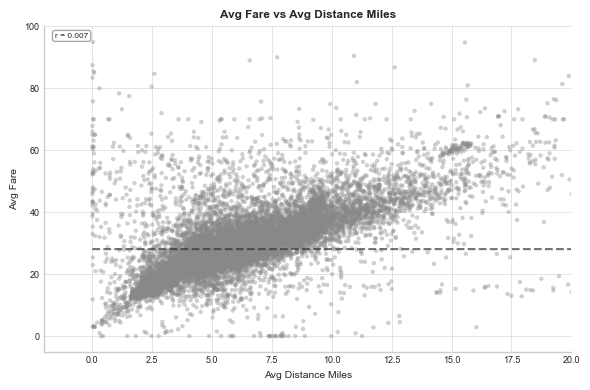

In [24]:
# mask = (sample_df['avg_distance_miles'] > .25) & (sample_df['avg_fare'] > .25)
plot_scatter(sample_df, 'avg_distance_miles', 'avg_fare',
             x_min=-2,
             x_max=20,
             y_min=-5, 
             y_max=100, 
             trend='linear')


### Avg Distance Miles vs Avg Fare by Borough

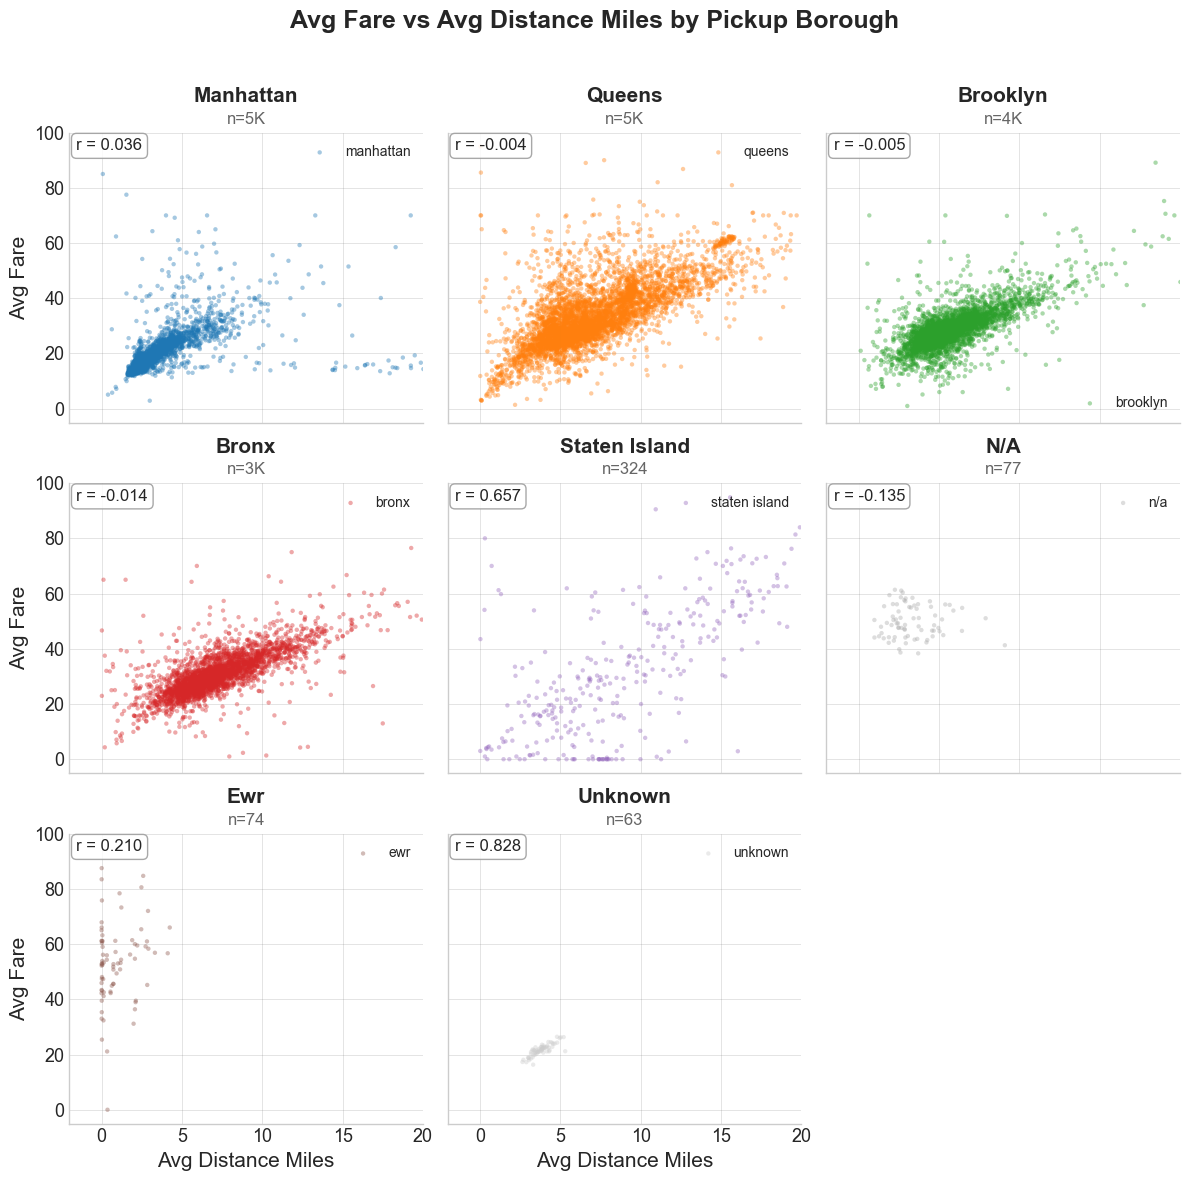

In [25]:
plot_scatter(
    df      = sample_df,              # DataFrame
    x_field = 'avg_distance_miles',  # numeric column for X
    y_field = 'avg_fare',          # numeric column for Y

    # ── Mode ──────────────────────────────────────────────────────
    group_field   = 'pickup_borough',           # None = single panel; e.g. 'borough' = grid
    color_field   = 'pickup_borough',           # color individual points by this categorical field
    #                                 # (e.g. color_field='borough' on a single-panel chart)

    # ── Decorations ───────────────────────────────────────────────
    # trend         = None,           # 'linear' = overlay regression line; None = skip
    # correlation   = True,           # True = show Pearson r badge in corner
    # log_x         = False,          # log-scale X
    # log_y         = False,          # log-scale Y

    # ── Manual axis limits (zoom past outliers) ──────────────────
    x_max         = 20,           # force upper bound on X (None = auto)
    y_max         = 100,           # force upper bound on Y (None = auto)
    x_min         = -2,           # force lower bound on X (None = auto)
    y_min         = -5,           # force lower bound on Y (None = auto)

    # ── Point appearance ──────────────────────────────────────────
    # alpha         = 0.4,            # point transparency (lower = denser overplot OK)
    # point_size    = 10,             # matplotlib `s` (points²)

    # ── Performance ───────────────────────────────────────────────
    # sample        = None,           # cap rendered points (e.g. 10_000) for huge frames
    # sample_seed   = 42,             # random seed for reproducible sampling

    # ── Grid mode layout ──────────────────────────────────────────
    # max_cols      = 3,              # max panels per row before wrapping
    # shared_axes   = True,           # True = shared X+Y across panels (for cross-compare)
    # panel_width   = 4.0,            # width per panel (inches)
    # panel_height  = 4.0,            # height per panel (inches)

    # ── Color ─────────────────────────────────────────────────────
    # color         = '#888888',      # single color when no palette applies
    # color_map     = None,           # dict value→color. None = BOROUGH_COLORS
    # default_color = '#888888',      # fallback for values not in color_map

    # ── Title ─────────────────────────────────────────────────────
    # title         = None,           # default auto: '<Y> vs <X>' or with 'by <Group>'
)

### Avg Fare vs Avg Tip by Borough

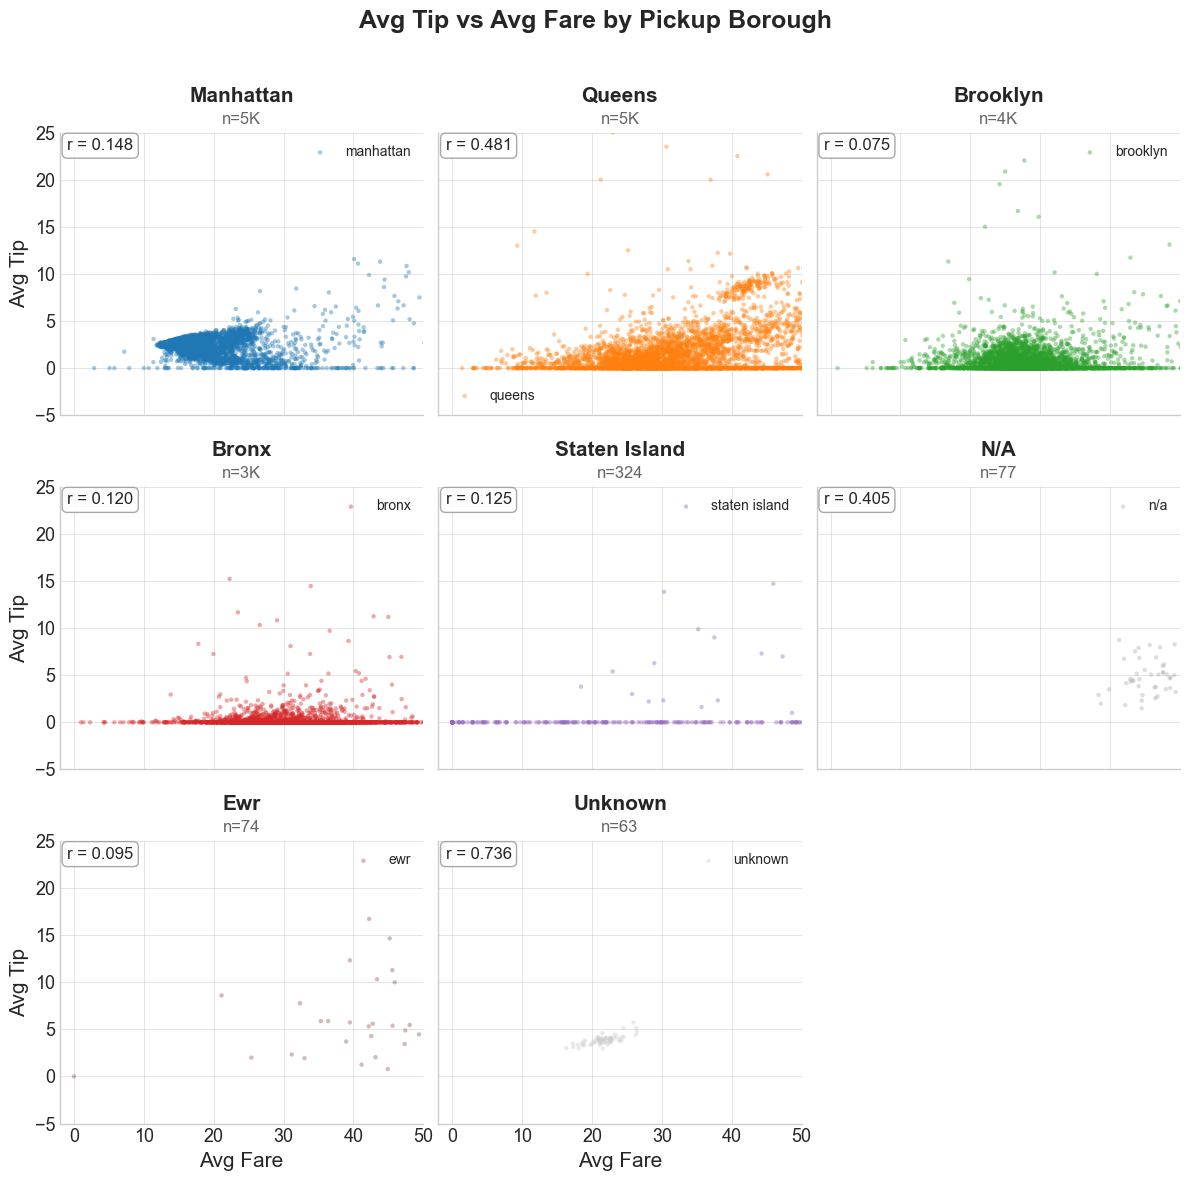

In [26]:
plot_scatter(
    df      = sample_df,              # DataFrame
    x_field = 'avg_fare',  # numeric column for X
    y_field = 'avg_tip',          # numeric column for Y

    # ── Mode ──────────────────────────────────────────────────────
    group_field   = 'pickup_borough',           # None = single panel; e.g. 'borough' = grid
    color_field   = 'pickup_borough',           # color individual points by this categorical field
    #                                 # (e.g. color_field='borough' on a single-panel chart)

    # ── Decorations ───────────────────────────────────────────────
    # trend         = None,           # 'linear' = overlay regression line; None = skip
    # correlation   = True,           # True = show Pearson r badge in corner
    # log_x         = False,          # log-scale X
    # log_y         = False,          # log-scale Y

    # ── Manual axis limits (zoom past outliers) ──────────────────
    x_max         = 50,           # force upper bound on X (None = auto)
    y_max         = 25,           # force upper bound on Y (None = auto)
    x_min         = -2,           # force lower bound on X (None = auto)
    y_min         = -5,           # force lower bound on Y (None = auto)

    # ── Point appearance ──────────────────────────────────────────
    # alpha         = 0.4,            # point transparency (lower = denser overplot OK)
    # point_size    = 10,             # matplotlib `s` (points²)

    # ── Performance ───────────────────────────────────────────────
    # sample        = None,           # cap rendered points (e.g. 10_000) for huge frames
    # sample_seed   = 42,             # random seed for reproducible sampling

    # ── Grid mode layout ──────────────────────────────────────────
    # max_cols      = 3,              # max panels per row before wrapping
    # shared_axes   = True,           # True = shared X+Y across panels (for cross-compare)
    # panel_width   = 4.0,            # width per panel (inches)
    # panel_height  = 4.0,            # height per panel (inches)

    # ── Color ─────────────────────────────────────────────────────
    # color         = '#888888',      # single color when no palette applies
    # color_map     = None,           # dict value→color. None = BOROUGH_COLORS
    # default_color = '#888888',      # fallback for values not in color_map

    # ── Title ─────────────────────────────────────────────────────
    # title         = None,           # default auto: '<Y> vs <X>' or with 'by <Group>'
)